+ 심리학/인지언어학에서 점화효과.
+ 딥러닝 계층을 깊게 쌓는 것과 비슷하다.
+ 깊게 쌓을 수록 더 추상적인 생각. 그렇다면 얼마나 깊게 쌓아야하는가?
+ 너무 깊게 쌓으면 사람이 딴 생각을 하듯, 딥러닝 네트워크 역시 다른 생각으로 빠질 수도 있을 것 같다.

<br>

> 문맥의 문제!! 단어의 모호성/중의성 등을 이미지에 기반한 priming effect로 해결할 수 있지 않을까???

In [29]:
import os
os.sys.path.append('../../official_github/')

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam
from ch7_CNN.simple_convnet import SimpleConvNet

from common.trainer import Trainer

In [31]:
test_dict = {}
train_dict = {}
root_path = './cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are originally (N, 3072 - H*W*C)
## If you want to convert them into numpy-standard (N, H, W, C) shape or torch-standard(N, C, H, W) run following codes.
def numpy2rgb(arr: np.ndarray, way: str='torch') -> np.ndarray:
    batch_size = len(arr)
    if way == 'torch':
        axes = (0,1,2,3)    ## saito's book <Deeplearning from scratch> way
    elif way == 'numpy':
        axes = (0,2,3,1)
    arr = arr.reshape(batch_size, 3, 32, 32).transpose(*axes)
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'], 'torch')
test_dict[b'data'] = numpy2rgb(test_dict[b'data'], 'torch')

In [32]:
print(train_dict[b'data'].shape, test_dict[b'data'].shape)

(50000, 3, 32, 32) (10000, 3, 32, 32)


In [33]:
x_train, t_train = train_dict[b'data'], train_dict[b'labels']
x_test, t_test = test_dict[b'data'], test_dict[b'labels']

In [34]:
conv1 = SimpleConvNet(input_dim=(3,32,32), 
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)


In [35]:
max_epochs = 10

In [36]:
trainer = Trainer(conv1, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

train loss:2.6998781549861626
=== epoch:1, train acc:0.102, test acc:0.102 ===
train loss:2.3165969710020318
train loss:2.3140639260011264
train loss:2.290388427838667
train loss:2.2958521464524537
train loss:2.268280673009846
train loss:2.267222905780066
train loss:2.245918091063334
train loss:2.2274718184577846
train loss:2.208804920962755
train loss:2.1788594746957197
train loss:2.188066019481882
train loss:2.190613131056885
train loss:2.1463327370249687
train loss:2.129315864054463
train loss:2.063118439870753
train loss:2.1818134239595195
train loss:2.1977805231154024
train loss:2.127563101945253
train loss:2.147933872963088
train loss:2.1984703564439663
train loss:2.061394843579726
train loss:2.18314930518675
train loss:2.0194574603585296
train loss:1.9410276934357646
train loss:2.0900335632666787
train loss:2.0305285352393274
train loss:2.0298059647788156
train loss:1.8526995920561644
train loss:2.0117192776048918
train loss:2.017887520549035
train loss:1.9945135221956898
train 

In [37]:
# max_epochs = 20
# train_size = x_train.shape[0]
# batch_size = 100

# iters = 5_000
# iter_per_epoch = max(train_size / batch_size, 1)

# learning_rate = 0.01

# network_dict = {'Conv1': SimpleConvNet(input_dim=(3,32,32), conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1}, hidden_size=100, output_size=10, weight_init_std=0.01)
#                 }

# output_dict = {}

# for key, network in network_dict.items():
#     net = network
#     optimizer = Adam(lr=learning_rate)

#     output_dict[f'{key} train acc'] = []
#     output_dict[f'{key} test acc'] = []
    
#     print(f'=== {key} network training start ===')
#     for i in tqdm(range(iters), leave=False):
#         batch_mask = np.random.choice(train_size, batch_size)
#         x_batch = x_train[batch_mask]
#         t_batch = t_train[batch_mask]

#         grads = net.gradient(x_batch, t_batch)
#         optimizer.update(net.params, grads)

#         if i % iter_per_epoch == 0:
#             train_acc = net.accuracy(x_train, t_train)
#             test_acc = net.accuracy(x_test, t_test)
#             output_dict[f'{key} train acc'].append(train_acc)
#             output_dict[f'{key} test acc'].append(test_acc)
#             print(f'=== {key} result report ===')
#             print(f'train_acc: {train_acc}, test_acc: {test_acc}')
    
    

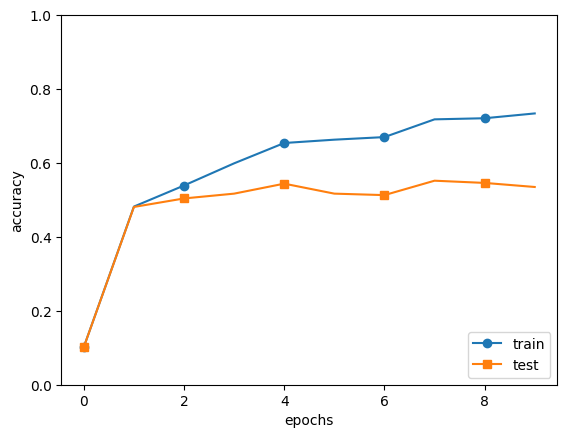

In [38]:
# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


### hyper parameters
  + max_epochs = 20
  + batch_size = 100
  + iters = 5_000
  + learning_rate = 0.01

<br>

### results
+ 